# Proyecto Introducción a la inteligencia artificial. Analisis factores que determinan la habilidad de un jugador y su rango de calificación en League of Legends



In [3]:
#Importar librerias

import seaborn as sns
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [4]:
data = pd.read_csv("./LeaguePlayerStats.csv")
data

,summonerName,summonerLevel,rank,wins,losses,winRate,kills,deaths,assists,prefLane,...,minionsKilled,goldEarned,turretTakedowns,visionScore,dragonKills,longestTimeSpentLiving,totalDamageDealt,totalDamageTaken,gameDuration,gameStart
0,RoséPosié,712,BRONZE,13,12,0.52,3.20,6.72,15.36,SUPPORT,...,50.32,8982.20,1,45.56,0,506.96,48651.12,544240,28.566667,7.216000
1,Xest,199,BRONZE,12,13,0.48,8.36,5.72,14.44,SUPPORT,...,47.40,11866.56,0,29.96,0,494.00,78143.68,441284,24.580667,16.400000
2,SilverHawk0,340,BRONZE,11,14,0.44,8.20,9.00,7.88,TOP,...,186.16,13236.60,1,19.96,0,438.64,150665.56,743065,30.250667,16.724667
3,Res93,61,BRONZE,12,13,0.48,8.60,7.52,8.20,ADC,...,190.00,13367.08,2,25.36,0,558.36,170517.52,594545,30.931333,17.265333
4,B3tterTh4nYo0,124,BRONZE,8,17,0.32,5.24,7.32,8.76,JUNGLE,...,97.76,11655.24,0,21.28,0,563.40,152541.04,652545,29.800000,13.505333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,DarkLady Lilith,516,SILVER,12,13,0.48,7.36,6.04,12.92,MIDDLE,...,138.36,12483.88,2,36.24,0,634.64,124161.88,540583,31.024000,15.213333
2281,IceTeaTs,241,SILVER,9,16,0.36,7.40,7.96,11.68,NONE,...,98.52,12285.04,1,9.44,0,346.32,97369.36,521546,22.320000,14.589333
2282,EasyEichel,312,SILVER,15,10,0.60,9.20,8.04,8.36,MIDDLE,...,87.72,13425.88,1,14.48,0,374.04,196456.52,809734,28.762667,15.082667
2283,popomu elleyin,520,SILVER,9,16,0.36,6.36,7.76,7.92,NONE,...,103.88,14513.68,1,24.40,0,404.08,143844.24,826660,29.032000,14.207333


### Análisis estadístico

In [5]:
#Dimensiones y datos
print("Dimensiones:")
print(data.shape)

print("\nTipos de datos:")
print(data.dtypes)

Dimensiones:
(2285, 21)

Tipos de datos:
summonerName                  str
summonerLevel               int64
rank                          str
wins                        int64
losses                      int64
winRate                   float64
kills                     float64
deaths                    float64
assists                   float64
prefLane                      str
campsKilled               float64
minionsKilled             float64
goldEarned                float64
turretTakedowns             int64
visionScore               float64
dragonKills                 int64
longestTimeSpentLiving    float64
totalDamageDealt          float64
totalDamageTaken            int64
gameDuration              float64
gameStart                 float64
dtype: object


In [6]:
#Estadisticas descriptivas
data.describe()

,summonerLevel,wins,losses,winRate,kills,deaths,assists,campsKilled,minionsKilled,goldEarned,turretTakedowns,visionScore,dragonKills,longestTimeSpentLiving,totalDamageDealt,totalDamageTaken,gameDuration,gameStart
count,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2285.000000,2.285000e+03,2285.000000,2285.000000
mean,397.775055,12.773742,12.200875,0.511553,6.736992,6.602602,8.988009,27.068491,114.281915,12068.454345,1.457330,22.834383,0.102407,525.862548,135230.686408,6.579966e+05,27.859433,15.286140
std,264.024415,3.072962,3.078426,0.122531,2.370627,1.570894,3.757180,38.655790,57.981056,1841.819902,0.744239,14.255612,0.332188,107.862196,51438.305929,1.554706e+05,2.660673,2.885436
min,29.000000,0.000000,2.000000,0.000000,0.000000,1.800000,0.320000,0.000000,0.240000,3464.400000,0.000000,0.000000,0.000000,195.760000,9671.600000,1.179100e+05,13.546000,3.696667
25%,196.000000,11.000000,10.000000,0.440000,5.280000,5.560000,6.360000,3.520000,60.840000,11032.240000,1.000000,14.000000,0.000000,459.480000,103381.280000,5.443930e+05,26.195333,13.732000
50%,354.000000,13.000000,12.000000,0.520000,6.720000,6.480000,8.000000,9.240000,113.640000,12231.400000,1.000000,18.800000,0.000000,527.960000,138053.120000,6.561850e+05,28.007333,15.729333
75%,554.000000,15.000000,14.000000,0.600000,8.240000,7.600000,10.800000,31.280000,164.240000,13269.480000,2.000000,26.440000,0.000000,601.920000,167582.040000,7.629430e+05,29.697333,17.285333
max,1755.000000,22.000000,25.000000,0.880000,15.440000,13.520000,31.680000,187.440000,248.920000,17637.840000,4.000000,90.720000,2.000000,864.440000,324115.160000,1.345198e+06,35.542667,22.054667


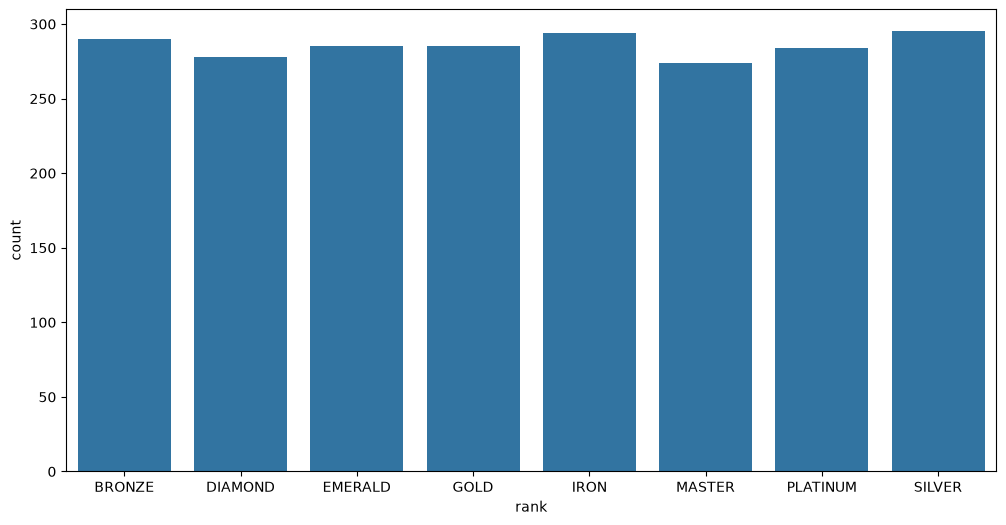

In [7]:
#Countplot de ranks (variable objetivo)
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x=data["rank"])
plt.show()

### Promedio de minionsKilled según el rank

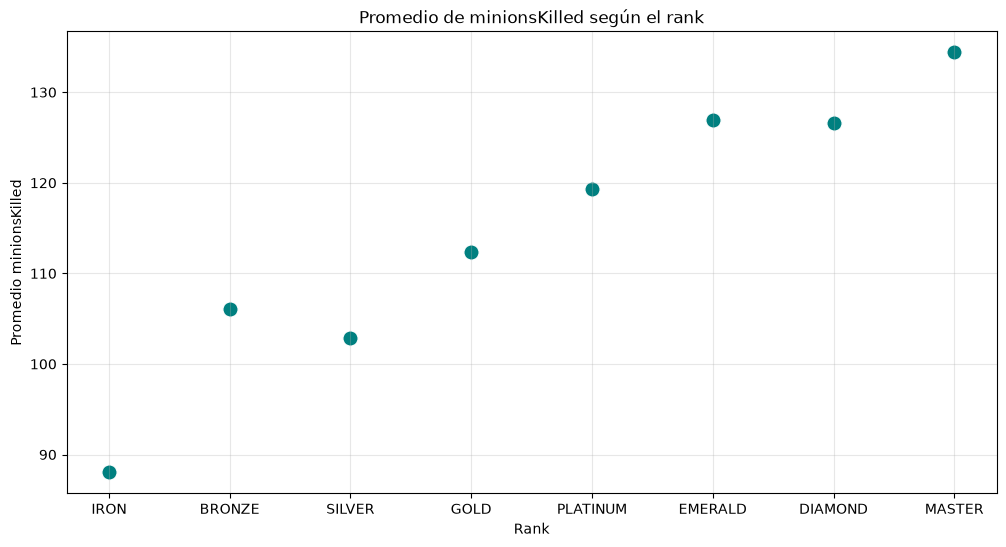

In [8]:
rank_order = ["IRON", "BRONZE", "SILVER", "GOLD", "PLATINUM", "EMERALD", "DIAMOND", "MASTER"]


# Promedio de minionsKilled agrupado por rank, respetando el orden
avg_minions = (
    data.groupby("rank")["minionsKilled"]
    .mean()
    .reindex(rank_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_minions, x="rank", y="minionsKilled", s=120, color="teal")
plt.title("Promedio de minionsKilled según el rank")
plt.xlabel("Rank")
plt.ylabel("Promedio minionsKilled")
plt.grid(True, alpha=0.3)
plt.show()

### Tiempo promedio por partida según el rank

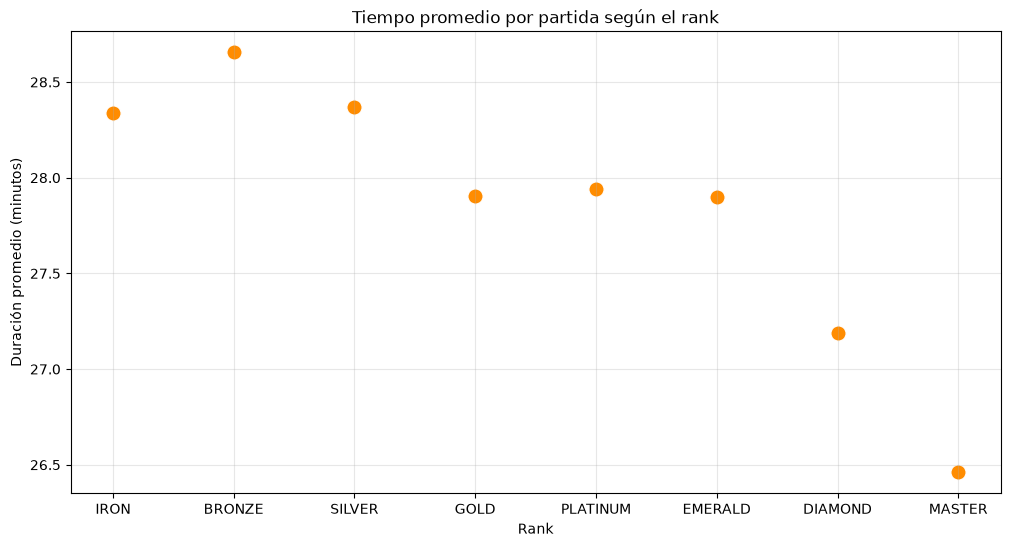

In [9]:
# Tiempo promedio por partida (gameDuration, en minutos) por rank

# Promedio de gameDuration agrupado por rank, respetando el orden
avg_duration = (
    data.groupby("rank")["gameDuration"]
    .mean()
    .reindex(rank_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_duration, x="rank", y="gameDuration", s=120, color="darkorange")
plt.title("Tiempo promedio por partida según el rank")
plt.xlabel("Rank")
plt.ylabel("Duración promedio (minutos)")
plt.grid(True, alpha=0.3)
plt.show()

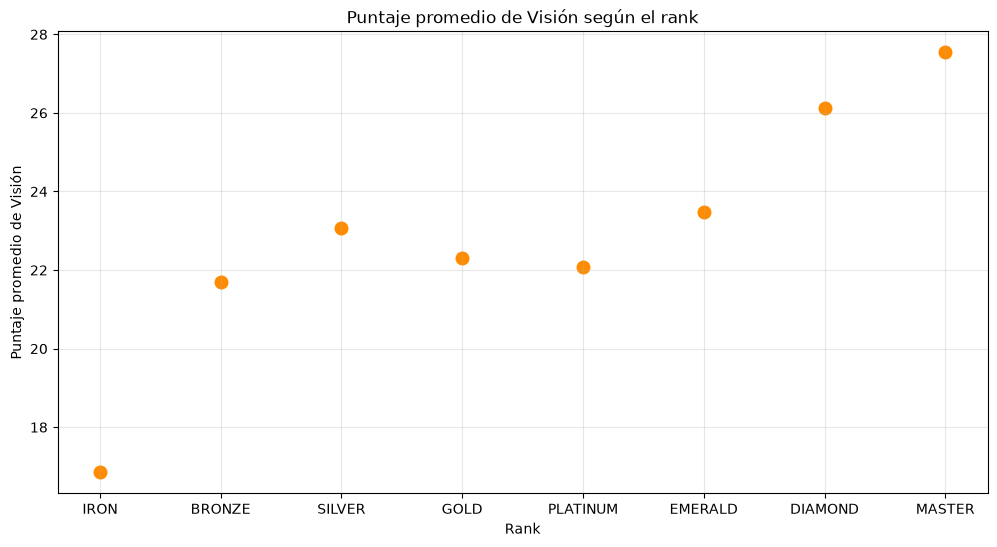

In [11]:
# Tiempo promedio por partida (gameDuration, en minutos) por rank

# Promedio de VisionScore agrupado por rank, respetando el orden
avg_vision_score = (
    data.groupby("rank")["visionScore"]
    .mean()
    .reindex(rank_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=avg_vision_score, x="rank", y="visionScore", s=120, color="darkorange")
plt.title("Puntaje promedio de Visión según el rank")
plt.xlabel("Rank")
plt.ylabel("Puntaje promedio de Visión")
plt.grid(True, alpha=0.3)
plt.show()

## Consideraciones
